# 05 - Forecasting Results & Visualisations

Loads the prediction CSVs from `results/predictions/` and the 2024 ground truth,
then produces all plots.

## Setup

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.config import RESULTS_DIR, PREDICTIONS_DIR
from src.utils.data_loader import load_test_data

print("Environment ready.")
print("Predictions dir:", PREDICTIONS_DIR)
print("Evaluation dir :", RESULTS_DIR / "evaluation")

Environment ready.
Predictions dir: c:\Users\cescedes\Documents\GitHub\rdkd\results\predictions
Evaluation dir : c:\Users\cescedes\Documents\GitHub\rdkd\results\evaluation


## Load Predictions & Ground Truth

In [2]:
test_wide = load_test_data()

pred_fw = pd.read_csv(PREDICTIONS_DIR / "predictions_2024_feature_ward.csv")
pred_ks = pd.read_csv(PREDICTIONS_DIR / "predictions_2024_kshape.csv")
pred_gl = pd.read_csv(PREDICTIONS_DIR / "predictions_2024_global.csv")

eval_fw = pd.read_csv(RESULTS_DIR / "evaluation" / "evaluation_summary_feature_ward.csv")
eval_ks = pd.read_csv(RESULTS_DIR / "evaluation" / "evaluation_summary_kshape.csv")
eval_gl = pd.read_csv(RESULTS_DIR / "evaluation" / "evaluation_summary_global.csv")

hh_fw = pd.read_csv(RESULTS_DIR / "evaluation" / "household_mae_feature_ward.csv")
hh_ks = pd.read_csv(RESULTS_DIR / "evaluation" / "household_mae_kshape.csv")
hh_gl = pd.read_csv(RESULTS_DIR / "evaluation" / "household_mae_global.csv")

bt_fw = pd.read_csv(RESULTS_DIR / "evaluation" / "backtest_selection_feature_ward.csv")
bt_ks = pd.read_csv(RESULTS_DIR / "evaluation" / "backtest_selection_kshape.csv")
bt_gl = pd.read_csv(RESULTS_DIR / "evaluation" / "backtest_selection_global.csv")

# Build comparison table once
comparison = pd.concat(
    [
        eval_fw.assign(method="feature_ward"),
        eval_ks.assign(method="kshape"),
        eval_gl.assign(method="global"),
    ],
    ignore_index=True,
)

comparison = comparison[
    [
        "method",
        "n_households_evaluated",
        "expected_days_per_household",
        "n_households_with_complete_366_days",
        "average_household_mae",
        "median_household_mae",
    ]
].sort_values("average_household_mae", ascending=True).reset_index(drop=True)

# Build one long-format actual table
def wide_to_long_for_actual(wide_df: pd.DataFrame) -> pd.DataFrame:
    df = wide_df.reset_index()
    id_col = df.columns[0]
    long_df = df.melt(id_vars=id_col, var_name="date", value_name="actual")
    long_df = long_df.rename(columns={id_col: "household_id"})
    long_df["date"] = pd.to_datetime(long_df["date"])
    return long_df.sort_values(["household_id", "date"]).reset_index(drop=True)

actual_long = wide_to_long_for_actual(test_wide)

# Attach actuals to predictions once for all later plots
def attach_actuals(pred_df: pd.DataFrame, method_name: str) -> pd.DataFrame:
    df = pred_df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.merge(actual_long, on=["household_id", "date"], how="left", validate="one_to_one")
    df["method"] = method_name
    df["abs_err"] = (df["actual"] - df["predicted"]).abs()
    return df

plot_fw = attach_actuals(pred_fw, "feature_ward")
plot_ks = attach_actuals(pred_ks, "kshape")
plot_gl = attach_actuals(pred_gl, "global")

plot_frames = {
    "feature_ward": plot_fw,
    "kshape": plot_ks,
    "global": plot_gl,
}

METHOD_LABELS = {
    "feature_ward": "Feature+Ward",
    "kshape": "k-Shape",
    "global": "Global",
}

print("Loaded prediction, evaluation, and backtest outputs.")
display(comparison)

Loaded prediction, evaluation, and backtest outputs.


,method,n_households_evaluated,expected_days_per_household,n_households_with_complete_366_days,average_household_mae,median_household_mae
0,feature_ward,17547,366,17547,3.940402,2.230138
1,kshape,17547,366,17547,4.167071,2.273118
2,global,17547,366,17547,4.348562,2.322294


## Per-Household MAE

The primary evaluation metric: MAE over 366 days per household, averaged across all households.

In [3]:
summary_df = pd.DataFrame(
    [
        {
            "Method": "Feature+Ward",
            "Avg HH MAE": hh_fw["mae"].mean(),
            "Median HH MAE": hh_fw["mae"].median(),
            "Std HH MAE": hh_fw["mae"].std(),
        },
        {
            "Method": "k-Shape",
            "Avg HH MAE": hh_ks["mae"].mean(),
            "Median HH MAE": hh_ks["mae"].median(),
            "Std HH MAE": hh_ks["mae"].std(),
        },
        {
            "Method": "Global",
            "Avg HH MAE": hh_gl["mae"].mean(),
            "Median HH MAE": hh_gl["mae"].median(),
            "Std HH MAE": hh_gl["mae"].std(),
        },
    ]
)

display(summary_df.round(4))

,Method,Avg HH MAE,Median HH MAE,Std HH MAE
0,Feature+Ward,3.9404,2.2301,5.6962
1,k-Shape,4.1671,2.2731,6.0704
2,Global,4.3486,2.3223,6.2039


## Official forecasting comparison

These results are read from the saved evaluation outputs generated by the
updated forecasting pipeline, rather than being recomputed manually in the
plotting notebook. This keeps the notebook aligned with the assignment-
compliant evaluation logic:
- MAE is computed per household over all 366 forecast days
- the final reported score is the average household MAE

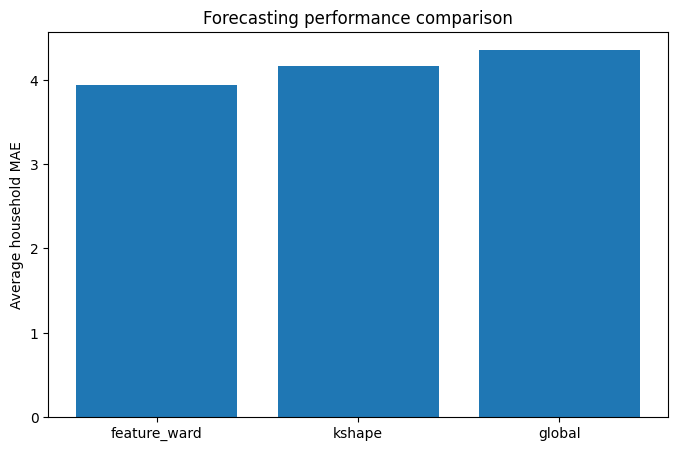

,method,n_households_evaluated,expected_days_per_household,n_households_with_complete_366_days,average_household_mae,median_household_mae
0,feature_ward,17547,366,17547,3.940402,2.230138
1,kshape,17547,366,17547,4.167071,2.273118
2,global,17547,366,17547,4.348562,2.322294


In [4]:
plot_df = comparison.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df["method"], plot_df["average_household_mae"])
plt.ylabel("Average household MAE")
plt.title("Forecasting performance comparison")
plt.show()

display(plot_df)

## Household MAE Distribution

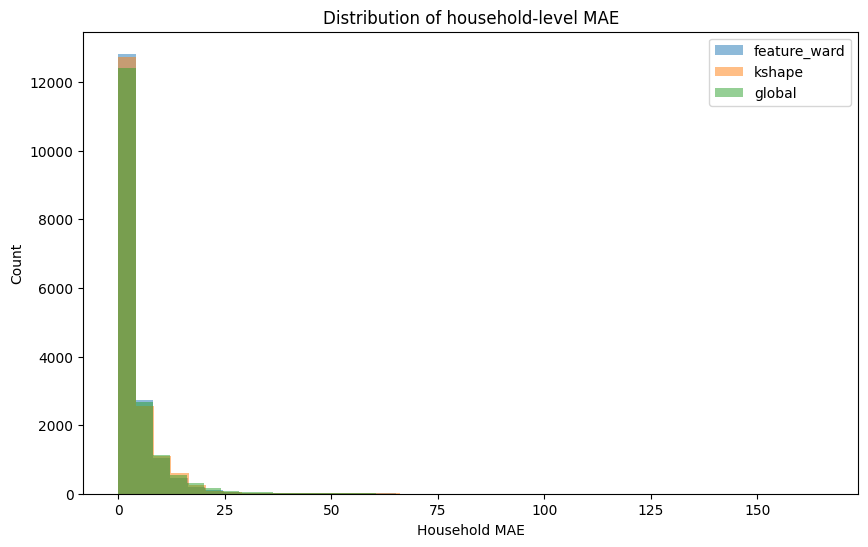

In [5]:
hh_fw_plot = hh_fw.copy()
hh_fw_plot["method"] = "feature_ward"

hh_ks_plot = hh_ks.copy()
hh_ks_plot["method"] = "kshape"

hh_gl_plot = hh_gl.copy()
hh_gl_plot["method"] = "global"

hh_all = pd.concat([hh_fw_plot, hh_ks_plot, hh_gl_plot], ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
for method_name in ["feature_ward", "kshape", "global"]:
    vals = hh_all.loc[hh_all["method"] == method_name, "mae"].dropna().values
    ax.hist(vals, bins=40, alpha=0.5, label=method_name)

ax.set_title("Distribution of household-level MAE")
ax.set_xlabel("Household MAE")
ax.set_ylabel("Count")
ax.legend()
plt.show()

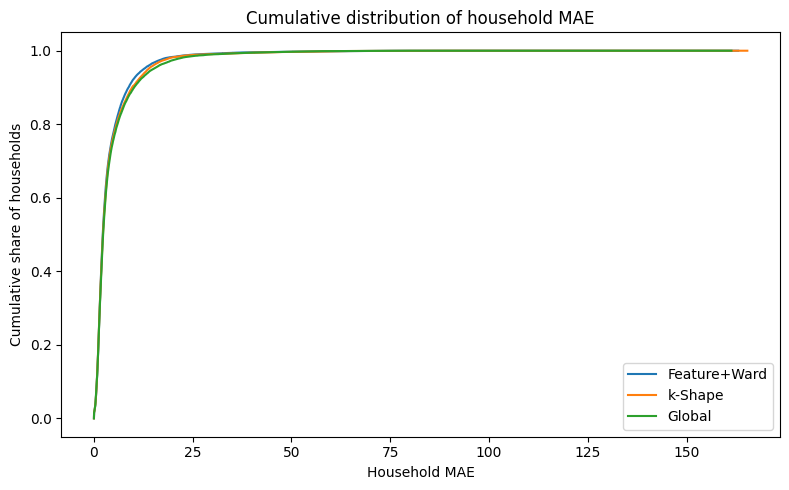

In [6]:
plt.figure(figsize=(8, 5))

for name, df in [
    ("Feature+Ward", hh_fw),
    ("k-Shape", hh_ks),
    ("Global", hh_gl),
]:
    vals = np.sort(df["mae"].dropna().values)
    y = np.arange(1, len(vals) + 1) / len(vals)
    plt.plot(vals, y, label=name)

plt.xlabel("Household MAE")
plt.ylabel("Cumulative share of households")
plt.title("Cumulative distribution of household MAE")
plt.legend()
plt.tight_layout()
plt.show()

## Cluster-level daily mean trajectories

For each clustering-based method, this section compares the average actual and
average predicted daily consumption within each cluster across 2024.

This is useful for checking whether each method captures seasonal shape and
cluster-level demand patterns, not just the overall MAE.

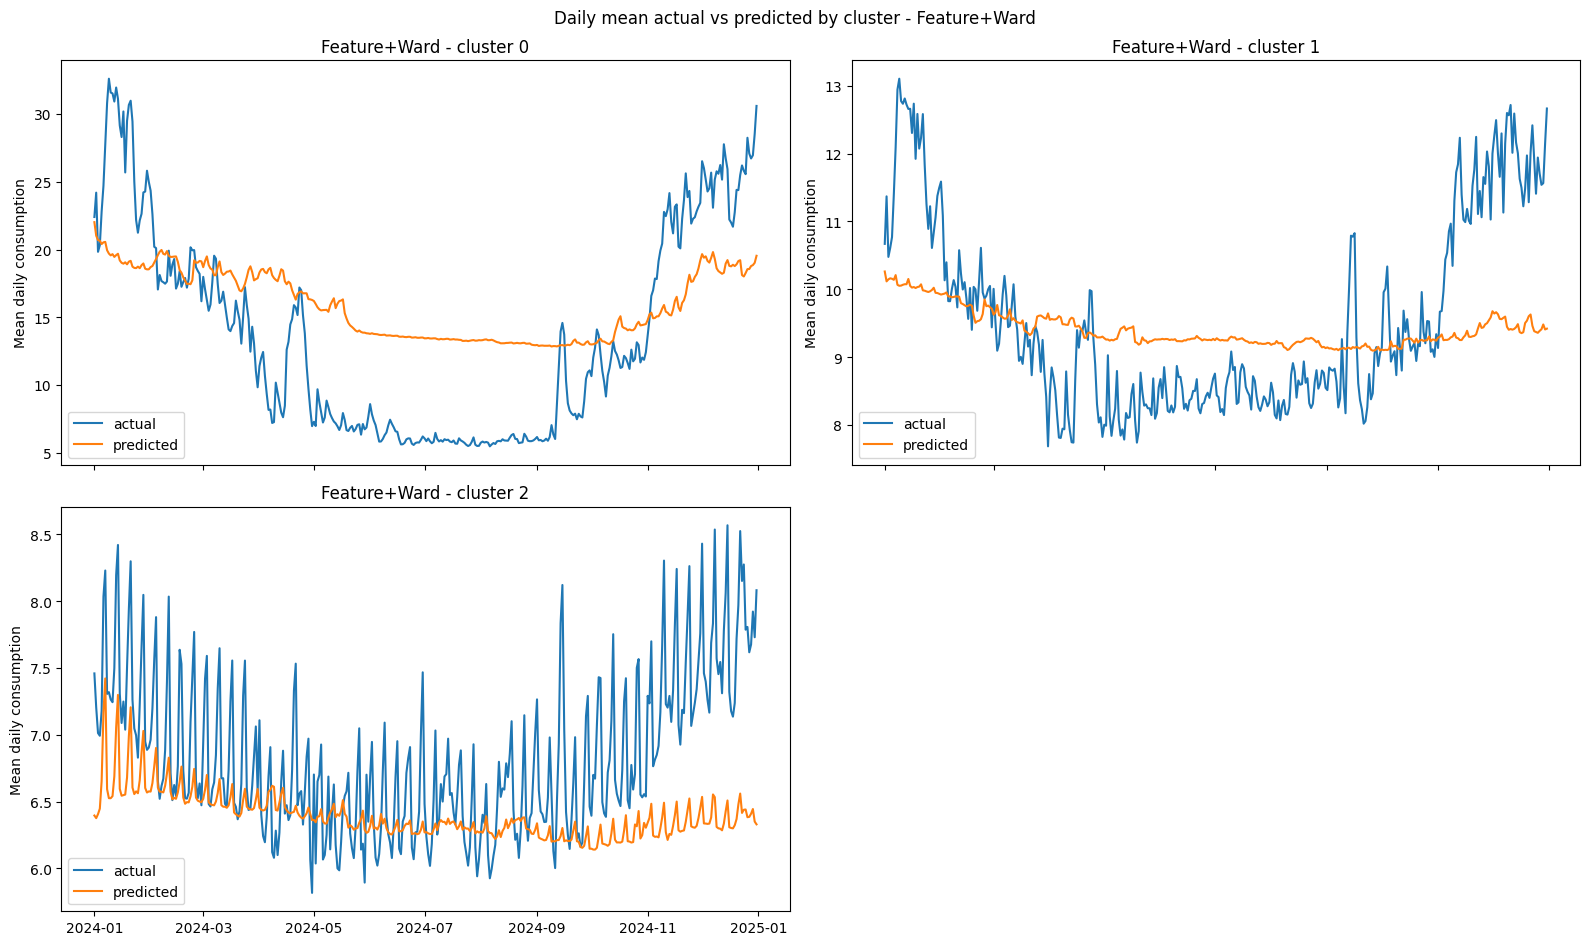

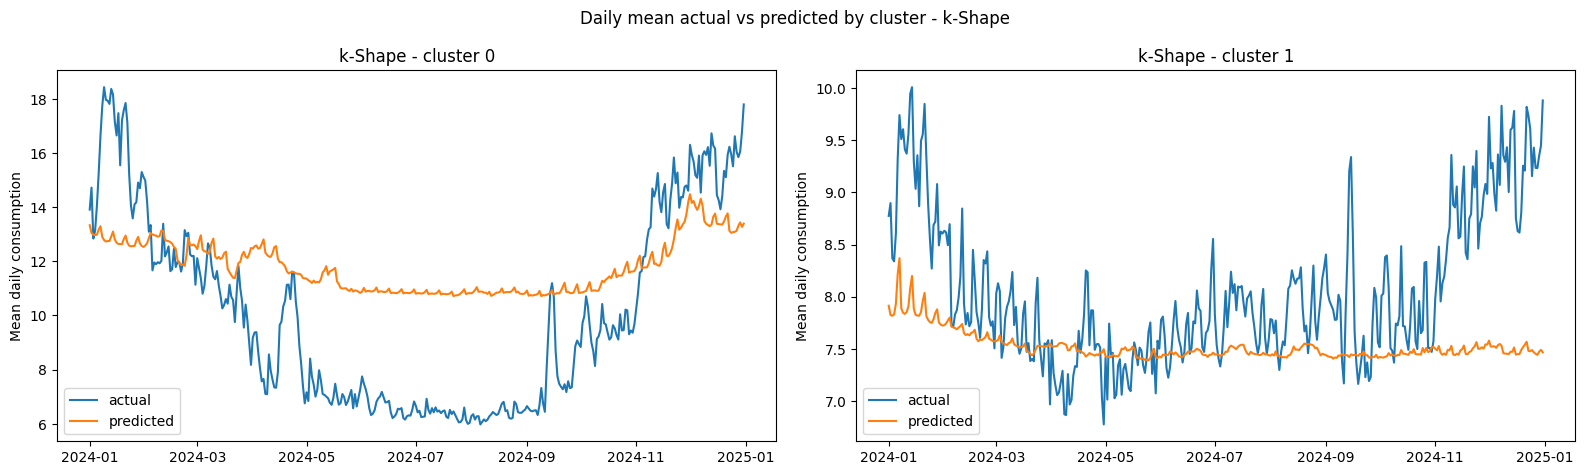

In [7]:
for method in ["feature_ward", "kshape"]:
    df = plot_frames[method].dropna(subset=["actual", "predicted"]).copy()
    reg_df = df[df["cluster"] >= 0]

    labels = sorted(reg_df["cluster"].unique().tolist())
    n = len(labels)
    ncols = 2
    nrows = max(1, (n + ncols - 1) // ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.8 * nrows), sharex=True)
    axes = np.array(axes).reshape(-1)

    for idx, label in enumerate(labels):
        sub = reg_df[reg_df["cluster"] == label].copy()
        daily = sub.groupby("date", as_index=False).agg(
            actual=("actual", "mean"),
            predicted=("predicted", "mean"),
        )

        ax = axes[idx]
        ax.plot(daily["date"], daily["actual"], label="actual")
        ax.plot(daily["date"], daily["predicted"], label="predicted")
        ax.set_title(f"{METHOD_LABELS[method]} - cluster {label}")
        ax.set_ylabel("Mean daily consumption")
        ax.legend()

    for j in range(len(labels), len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"Daily mean actual vs predicted by cluster - {METHOD_LABELS[method]}")
    plt.tight_layout()
    plt.show()

## Per-Cluster MAE

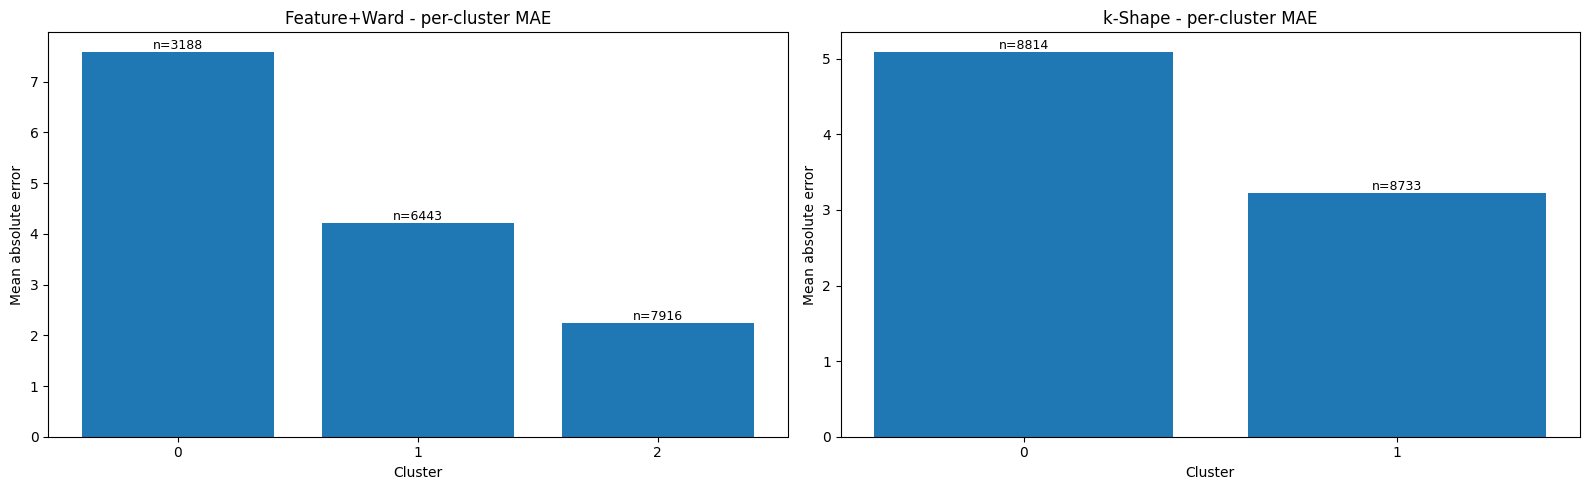

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

for ax, method in zip(axes, ["feature_ward", "kshape"]):
    df = plot_frames[method].dropna(subset=["actual", "predicted"]).copy()
    reg_df = df[df["cluster"] >= 0]

    cluster_mae = (
        reg_df.groupby("cluster", as_index=False)
        .agg(
            mae=("abs_err", "mean"),
            n_households=("household_id", "nunique"),
        )
        .sort_values("cluster")
    )

    ax.bar(cluster_mae["cluster"].astype(str), cluster_mae["mae"])
    ax.set_title(f"{METHOD_LABELS[method]} - per-cluster MAE")
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean absolute error")

    for x, y, n_hh in zip(cluster_mae["cluster"].astype(str), cluster_mae["mae"], cluster_mae["n_households"]):
        ax.text(x, y, f"n={n_hh}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Seasonal Error Pattern (Monthly MAE)

Shows which months are hardest to forecast.
Spikes in winter or summer reveal where the model struggles.

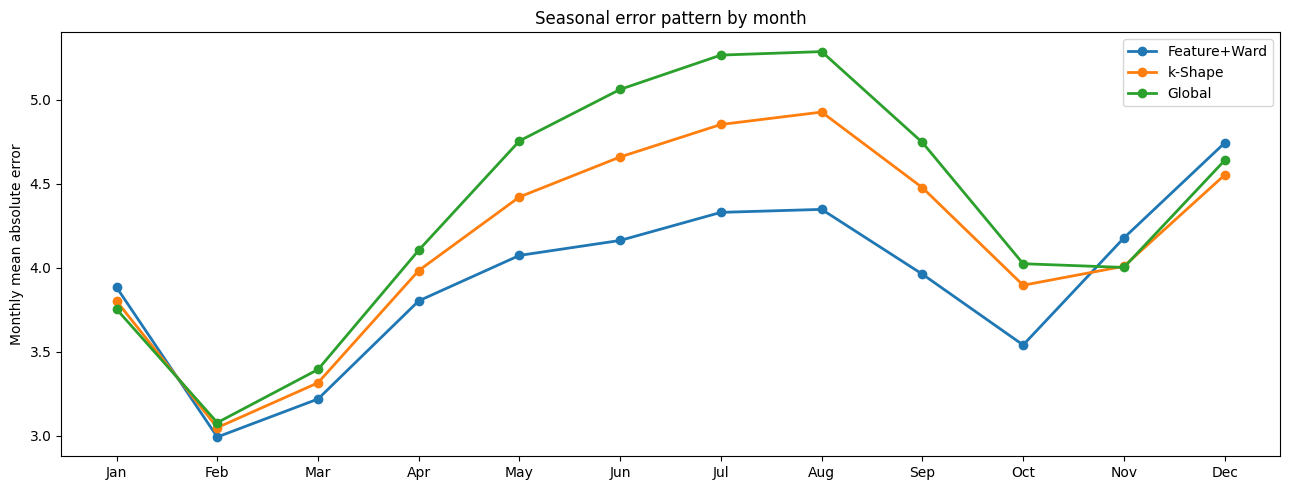

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for method in ["feature_ward", "kshape", "global"]:
    df = plot_frames[method].dropna(subset=["actual", "predicted"]).copy()
    df["month"] = pd.to_datetime(df["date"]).dt.month

    monthly = (
        df.groupby("month", as_index=False)["abs_err"]
        .mean()
        .set_index("month")["abs_err"]
        .reindex(range(1, 13))
    )

    ax.plot(
        monthly.index,
        monthly.values,
        marker="o",
        linewidth=2,
        label=METHOD_LABELS[method],
    )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names)
ax.set_ylabel("Monthly mean absolute error")
ax.set_title("Seasonal error pattern by month")
ax.legend()
plt.tight_layout()
plt.show()

## Forecasting feature set and model interpretation

The updated forecasting pipeline uses:
- lag and rolling-history features
- raw calendar features
- cyclic calendar encodings
- stable household mean from 2023 only
- cluster-derived seasonal priors from 2023 only

Below we show the feature set and model importances from the saved LightGBM models.

In [10]:
feature_cols_updated = [
    "lag_1", "lag_7", "lag_14", "lag_30",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "rolling_mean_30", "rolling_std_30",
    "day_of_week", "month", "day_of_year", "is_weekend", "week_of_year",
    "day_of_year_sin", "day_of_year_cos",
    "week_of_year_sin", "week_of_year_cos",
    "household_mean",
    "cluster_dow_mean", "cluster_month_mean",
    "household_minus_cluster_dow_mean",
    "household_minus_cluster_month_mean",
]

feature_table = pd.DataFrame({
    "feature": feature_cols_updated,
    "group": [
        "lag", "lag", "lag", "lag",
        "rolling", "rolling",
        "rolling", "rolling",
        "rolling", "rolling",
        "calendar", "calendar", "calendar", "calendar", "calendar",
        "cyclic_calendar", "cyclic_calendar",
        "cyclic_calendar", "cyclic_calendar",
        "household_level",
        "cluster_prior", "cluster_prior",
        "cluster_prior_offset",
        "cluster_prior_offset",
    ]
})

display(feature_table)

,feature,group
0,lag_1,lag
1,lag_7,lag
2,lag_14,lag
3,lag_30,lag
4,rolling_mean_7,rolling
5,rolling_std_7,rolling
6,rolling_mean_14,rolling
7,rolling_std_14,rolling
8,rolling_mean_30,rolling
9,rolling_std_30,rolling


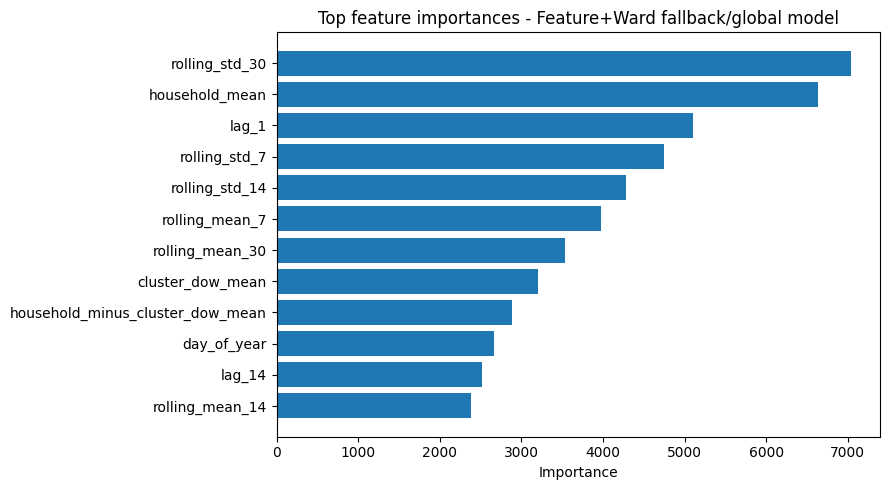

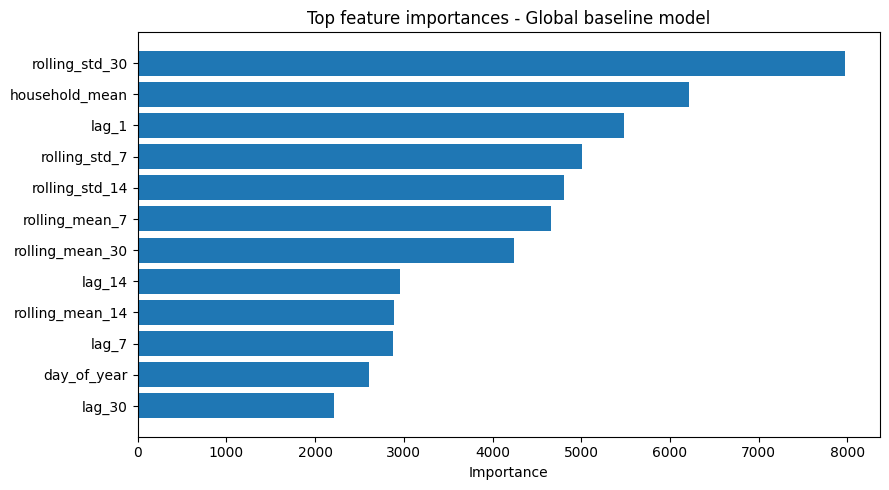

In [20]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

def load_model(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Must match the EXACT order used in training
feature_cols_updated = [
    "lag_1", "lag_7", "lag_14", "lag_30",
    "rolling_mean_7", "rolling_std_7",
    "rolling_mean_14", "rolling_std_14",
    "rolling_mean_30", "rolling_std_30",
    "day_of_week", "month", "day_of_year", "is_weekend", "week_of_year",
    "day_of_year_sin", "day_of_year_cos",
    "week_of_year_sin", "week_of_year_cos",
    "household_mean",
    "cluster_dow_mean", "cluster_month_mean",
    "household_minus_cluster_dow_mean",
    "household_minus_cluster_month_mean",
]

def plot_top_importances(model, feature_names, title, top_n=12):
    importances = model.feature_importances_

    if len(feature_names) != len(importances):
        raise ValueError(
            f"Feature-name length ({len(feature_names)}) does not match "
            f"model importance length ({len(importances)})."
        )

    imp = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False).head(top_n)

    imp = imp.iloc[::-1]

    plt.figure(figsize=(9, 5))
    plt.barh(imp["feature"], imp["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

fw_model = load_model(RESULTS_DIR / "models" / "feature_ward" / "lgbm_global.pkl")
gl_model = load_model(RESULTS_DIR / "models" / "global" / "lgbm_global.pkl")

plot_top_importances(
    fw_model,
    feature_cols_updated,
    "Top feature importances - Feature+Ward fallback/global model"
)

plot_top_importances(
    gl_model,
    feature_cols_updated,
    "Top feature importances - Global baseline model"
)

## Example households and error extremes

This section shows:
- example household trajectories (best and worst cases under Feature+Ward)
- the households with the lowest and highest household-level MAE for each method

These examples make the summary metrics easier to interpret.

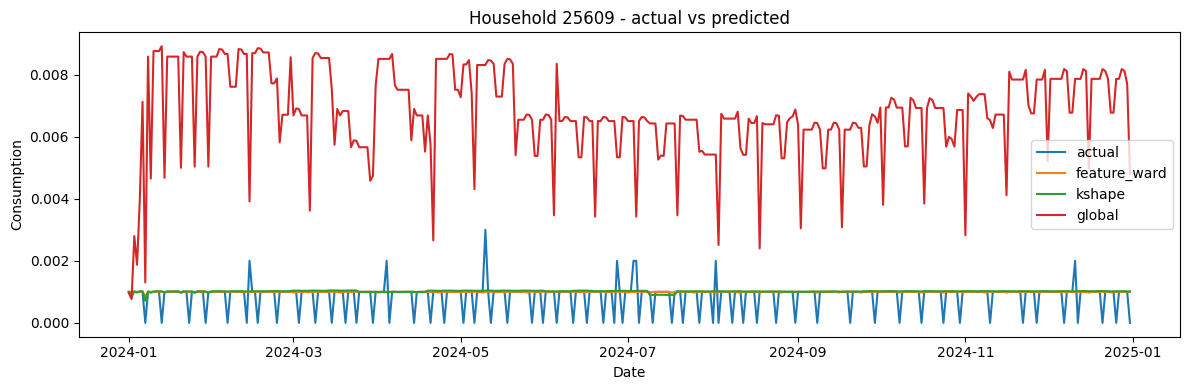

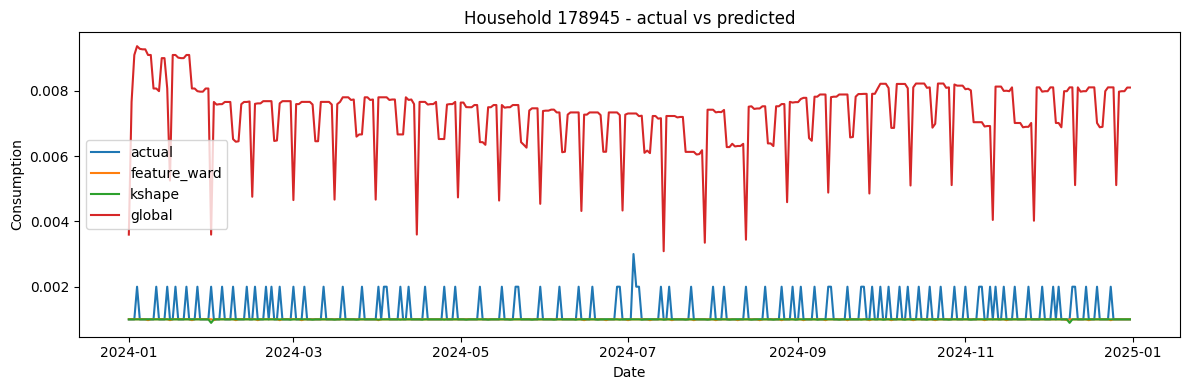

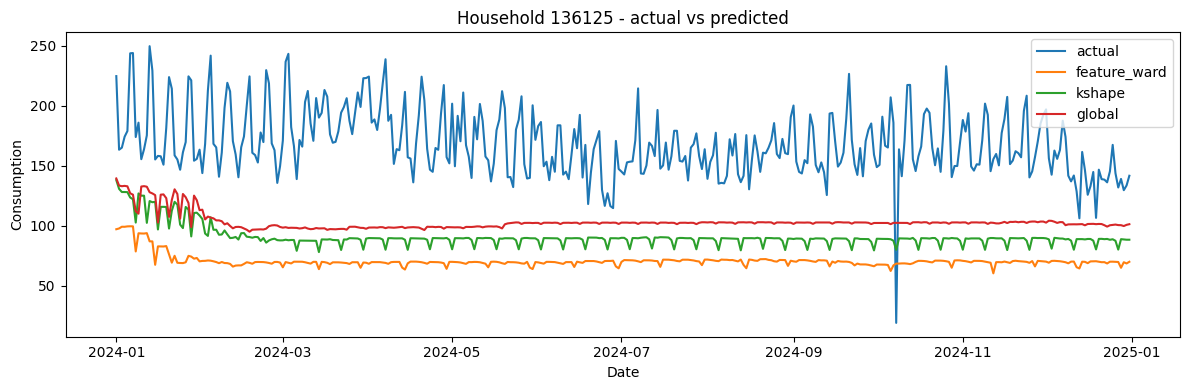

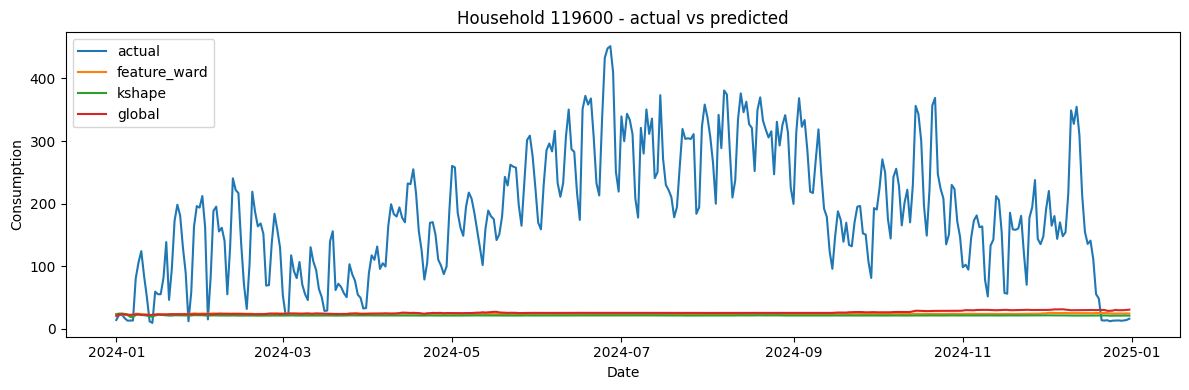

In [12]:
best_ids = hh_fw.sort_values("mae").head(2)["household_id"].tolist()
worst_ids = hh_fw.sort_values("mae").tail(2)["household_id"].tolist()
example_households = list(dict.fromkeys(best_ids + worst_ids))

for hh_id in example_households:
    actual_hh = actual_long.loc[actual_long["household_id"] == hh_id].copy()
    fw_hh = pred_fw.loc[pred_fw["household_id"] == hh_id].copy()
    ks_hh = pred_ks.loc[pred_ks["household_id"] == hh_id].copy()
    gl_hh = pred_gl.loc[pred_gl["household_id"] == hh_id].copy()

    fw_hh["date"] = pd.to_datetime(fw_hh["date"])
    ks_hh["date"] = pd.to_datetime(ks_hh["date"])
    gl_hh["date"] = pd.to_datetime(gl_hh["date"])

    plt.figure(figsize=(12, 4))
    plt.plot(actual_hh["date"], actual_hh["actual"], label="actual")
    plt.plot(fw_hh["date"], fw_hh["predicted"], label="feature_ward")
    plt.plot(ks_hh["date"], ks_hh["predicted"], label="kshape")
    plt.plot(gl_hh["date"], gl_hh["predicted"], label="global")
    plt.title(f"Household {hh_id} - actual vs predicted")
    plt.xlabel("Date")
    plt.ylabel("Consumption")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [13]:
top_n = 10

print("Best households by method (lowest MAE)")
for name, df in [("feature_ward", hh_fw), ("kshape", hh_ks), ("global", hh_gl)]:
    print(f"\n{name}")
    display(df.nsmallest(top_n, "mae"))

print("\nWorst households by method (highest MAE)")
for name, df in [("feature_ward", hh_fw), ("kshape", hh_ks), ("global", hh_gl)]:
    print(f"\n{name}")
    display(df.nlargest(top_n, "mae"))

Best households by method (lowest MAE)

feature_ward


,household_id,mae,n_days_compared,complete_horizon_flag
1455,25609,0.000183,366,True
10166,178945,0.000227,366,True
2467,43786,0.000228,366,True
5009,87238,0.000739,366,True
7976,139101,0.000854,366,True
17466,303585,0.000961,366,True
2160,37777,0.000961,366,True
13429,235014,0.000963,366,True
14517,253029,0.000967,366,True
15033,261540,0.000967,366,True



kshape


,household_id,mae,n_days_compared,complete_horizon_flag
1455,25609,0.000201,366,True
10166,178945,0.000226,366,True
2467,43786,0.000227,366,True
4211,74219,0.000870,366,True
13429,235014,0.000961,366,True
15926,277085,0.000961,366,True
5074,88327,0.000976,366,True
13550,236912,0.000976,366,True
16474,286577,0.000976,366,True
5967,103647,0.000976,366,True



global


...

,household_id,mae,n_days_compared,complete_horizon_flag
6880,119600,163.077360,366,True
7813,136125,98.142896,366,True
4927,85752,88.857877,366,True
3217,56963,82.384240,366,True
15603,271540,75.783121,366,True
15870,276175,74.141305,366,True
14979,260588,74.046735,366,True
12478,218084,73.426438,366,True
8610,150866,72.806423,366,True
6595,114438,72.522970,366,True



kshape


,household_id,mae,n_days_compared,complete_horizon_flag
6880,119600,165.398353,366,True
1874,32567,89.039549,366,True
3217,56963,85.408915,366,True
4927,85752,84.408660,366,True
13377,233942,81.671156,366,True
9560,167582,79.564425,366,True
8176,142918,78.645551,366,True
7813,136125,78.215363,366,True
6595,114438,72.990004,366,True
15603,271540,71.473717,366,True



global


,household_id,mae,n_days_compared,complete_horizon_flag
6880,119600,161.371510,366,True
13377,233942,79.881278,366,True
3217,56963,79.823196,366,True
1874,32567,79.134291,366,True
4927,85752,75.972465,366,True
9560,167582,75.226314,366,True
6595,114438,73.253000,366,True
15870,276175,72.720752,366,True
4723,82563,69.461553,366,True
4166,73380,66.780443,366,True


## pairwise household win-rate

,comparison,count,pct
0,Feature+Ward < Global,10607,60.449080
1,k-Shape < Global,10467,59.651222
2,Feature+Ward < k-Shape,9300,53.000513


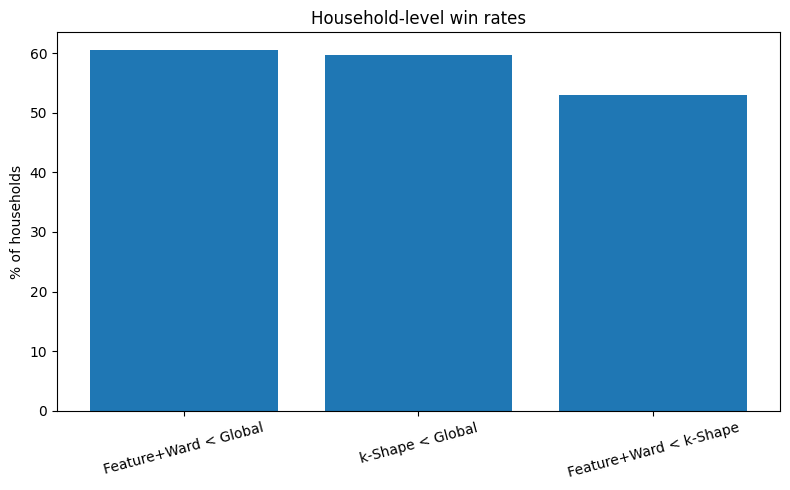

In [14]:
hh_compare = (
    hh_fw[["household_id", "mae"]].rename(columns={"mae": "mae_feature_ward"})
    .merge(
        hh_ks[["household_id", "mae"]].rename(columns={"mae": "mae_kshape"}),
        on="household_id",
        how="inner",
    )
    .merge(
        hh_gl[["household_id", "mae"]].rename(columns={"mae": "mae_global"}),
        on="household_id",
        how="inner",
    )
)

win_counts = pd.DataFrame({
    "comparison": [
        "Feature+Ward < Global",
        "k-Shape < Global",
        "Feature+Ward < k-Shape",
    ],
    "count": [
        (hh_compare["mae_feature_ward"] < hh_compare["mae_global"]).sum(),
        (hh_compare["mae_kshape"] < hh_compare["mae_global"]).sum(),
        (hh_compare["mae_feature_ward"] < hh_compare["mae_kshape"]).sum(),
    ],
})

win_counts["pct"] = 100 * win_counts["count"] / len(hh_compare)

display(win_counts)

plt.figure(figsize=(8, 5))
plt.bar(win_counts["comparison"], win_counts["pct"])
plt.ylabel("% of households")
plt.title("Household-level win rates")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## household MAE scatter vs Global

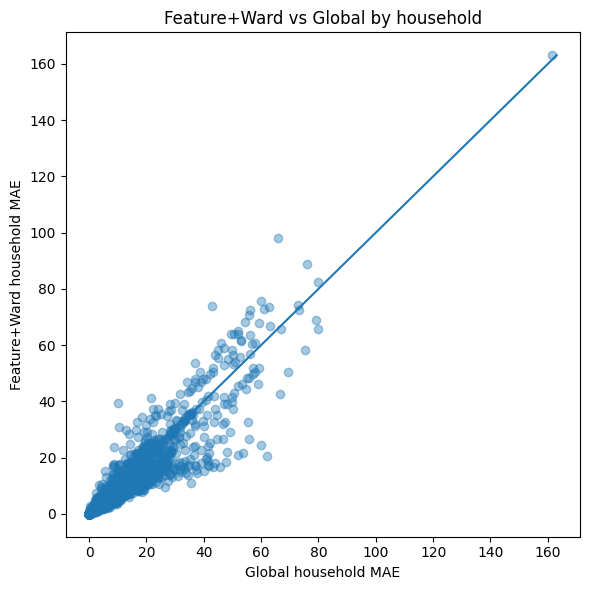

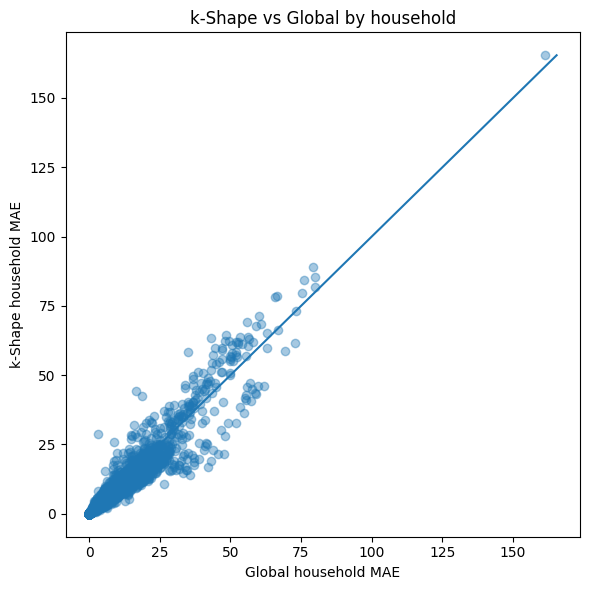

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(hh_compare["mae_global"], hh_compare["mae_feature_ward"], alpha=0.4)
mx = max(hh_compare["mae_global"].max(), hh_compare["mae_feature_ward"].max())
plt.plot([0, mx], [0, mx])
plt.xlabel("Global household MAE")
plt.ylabel("Feature+Ward household MAE")
plt.title("Feature+Ward vs Global by household")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(hh_compare["mae_global"], hh_compare["mae_kshape"], alpha=0.4)
mx = max(hh_compare["mae_global"].max(), hh_compare["mae_kshape"].max())
plt.plot([0, mx], [0, mx])
plt.xlabel("Global household MAE")
plt.ylabel("k-Shape household MAE")
plt.title("k-Shape vs Global by household")
plt.tight_layout()
plt.show()

## cluster size vs cluster MAE

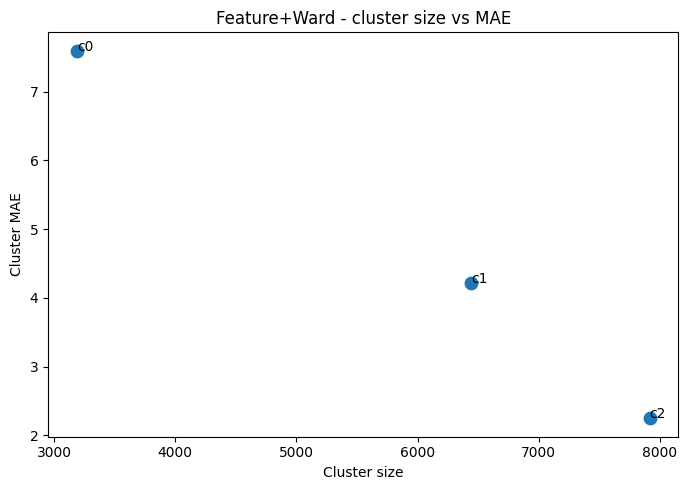

,cluster,mae,n_households
0,0,7.595418,3188
1,1,4.212845,6443
2,2,2.246674,7916


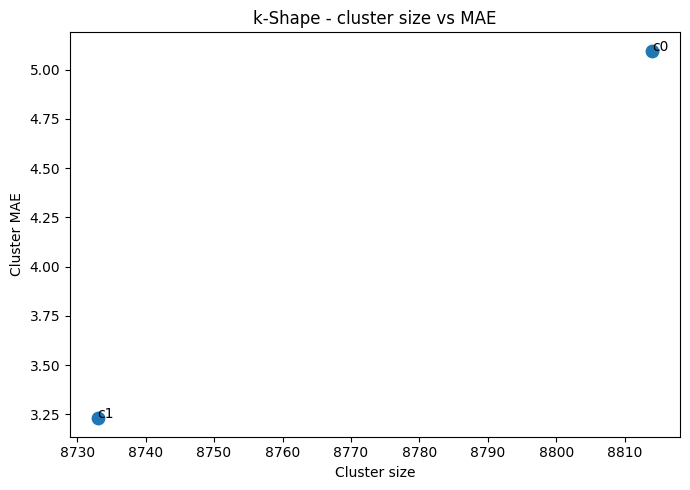

,cluster,mae,n_households
0,0,5.095422,8814
1,1,3.230110,8733


In [16]:
for method in ["feature_ward", "kshape"]:
    df = plot_frames[method].dropna(subset=["actual", "predicted"]).copy()
    reg_df = df[df["cluster"] >= 0]

    cluster_stats = (
        reg_df.groupby("cluster", as_index=False)
        .agg(
            mae=("abs_err", "mean"),
            n_households=("household_id", "nunique"),
        )
        .sort_values("cluster")
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(cluster_stats["n_households"], cluster_stats["mae"], s=80)
    for _, row in cluster_stats.iterrows():
        plt.text(row["n_households"], row["mae"], f"c{int(row['cluster'])}")
    plt.xlabel("Cluster size")
    plt.ylabel("Cluster MAE")
    plt.title(f"{METHOD_LABELS[method]} - cluster size vs MAE")
    plt.tight_layout()
    plt.show()

    display(cluster_stats)

## 2023-only backtest model selection

The updated forecasting pipeline now performs parameter selection using
rolling validation on 2023 only. The tables below summarize the candidate
parameter sets that were evaluated before final training on full 2023.

In [17]:
print("Feature+Ward backtest results")
display(bt_fw.sort_values(["scope", "mean_mae", "candidate_id"]))

print("\nk-Shape backtest results")
display(bt_ks.sort_values(["scope", "mean_mae", "candidate_id"]))

print("\nGlobal backtest results")
display(bt_gl.sort_values(["mean_mae", "candidate_id"]))

Feature+Ward backtest results


,candidate_id,mean_mae,n_successful_splits,n_estimators,learning_rate,num_leaves,min_child_samples,scope
0,0,3.867287,3,300,0.05,31,20,cluster_0
1,3,3.909646,3,500,0.03,127,40,cluster_0
2,2,3.921450,3,700,0.03,63,30,cluster_0
3,1,3.966146,3,500,0.05,63,20,cluster_0
4,3,2.460652,3,500,0.03,127,40,cluster_1
5,2,2.472362,3,700,0.03,63,30,cluster_1
6,1,2.473974,3,500,0.05,63,20,cluster_1
7,0,2.491514,3,300,0.05,31,20,cluster_1
8,3,1.759011,3,500,0.03,127,40,cluster_2
9,1,1.760659,3,500,0.05,63,20,cluster_2



k-Shape backtest results


,candidate_id,mean_mae,n_successful_splits,n_estimators,learning_rate,num_leaves,min_child_samples,scope
0,0,2.801351,3,300,0.05,31,20,cluster_0
1,2,2.813466,3,700,0.03,63,30,cluster_0
2,3,2.824973,3,500,0.03,127,40,cluster_0
3,1,2.831076,3,500,0.05,63,20,cluster_0
4,3,2.063732,3,500,0.03,127,40,cluster_1
5,2,2.071902,3,700,0.03,63,30,cluster_1
6,1,2.075978,3,500,0.05,63,20,cluster_1
7,0,2.088731,3,300,0.05,31,20,cluster_1
8,3,2.441724,3,500,0.03,127,40,global
9,1,2.447560,3,500,0.05,63,20,global



Global backtest results


,candidate_id,mean_mae,n_successful_splits,n_estimators,learning_rate,num_leaves,min_child_samples
0,3,2.448110,3,500,0.03,127,40
1,2,2.448841,3,700,0.03,63,30
2,1,2.454483,3,500,0.05,63,20
3,0,2.459733,3,300,0.05,31,20


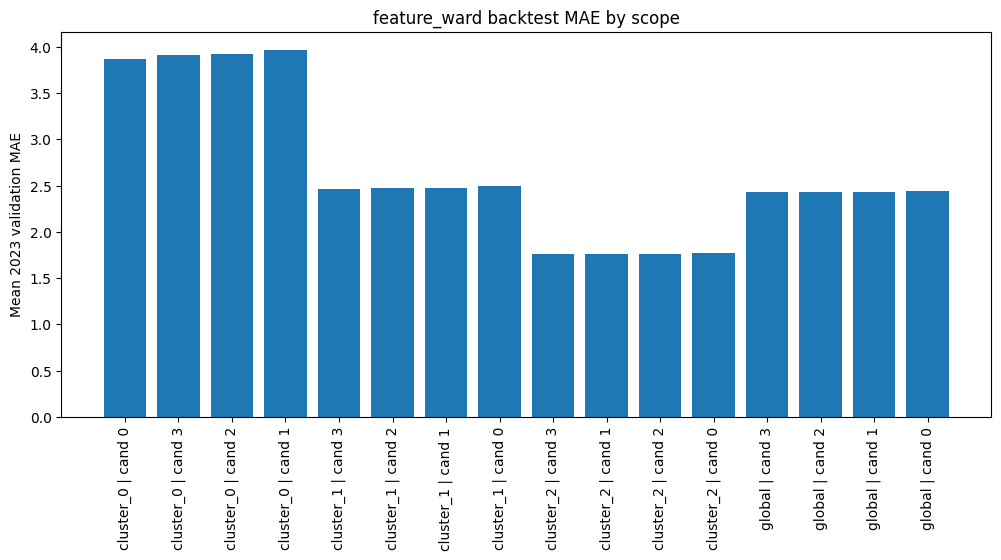

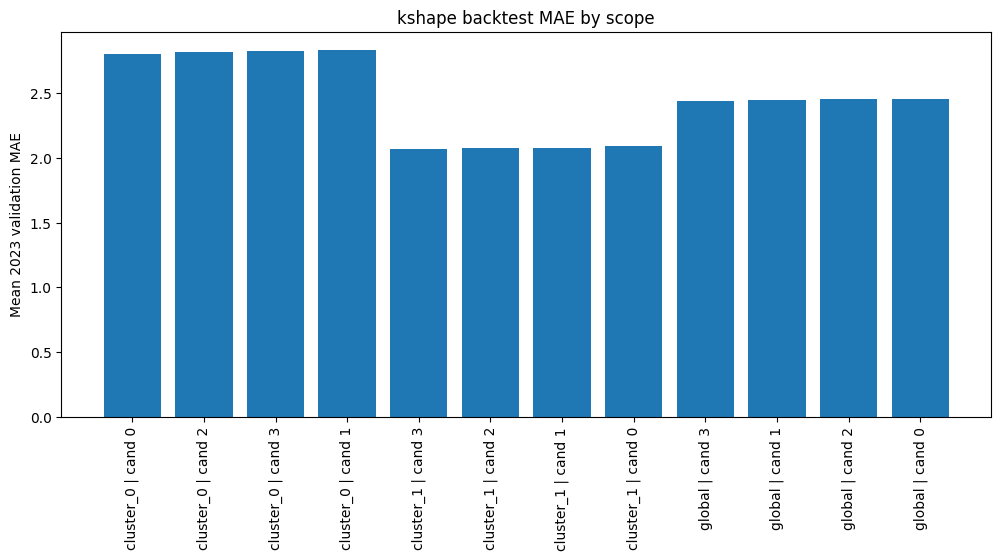

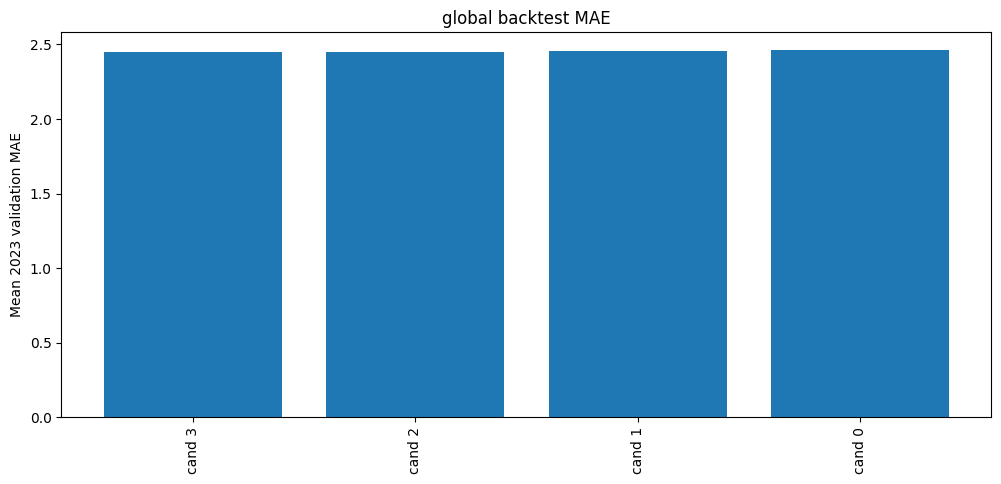

In [18]:
for title, df in [
    ("feature_ward backtest MAE by scope", bt_fw),
    ("kshape backtest MAE by scope", bt_ks),
    ("global backtest MAE", bt_gl),
]:
    plot_df = df.copy()
    plot_df["label"] = (
        plot_df["scope"].astype(str) + " | cand " + plot_df["candidate_id"].astype(str)
        if "scope" in plot_df.columns
        else "cand " + plot_df["candidate_id"].astype(str)
    )

    plt.figure(figsize=(12, 5))
    plt.bar(plot_df["label"], plot_df["mean_mae"])
    plt.title(title)
    plt.ylabel("Mean 2023 validation MAE")
    plt.xticks(rotation=90)
    plt.show()

## Summary

In [19]:
final_summary = comparison.copy().sort_values("average_household_mae").reset_index(drop=True)

print("Final forecasting comparison")
display(final_summary)

best_method = final_summary.iloc[0]["method"]
best_score = final_summary.iloc[0]["average_household_mae"]

print(f"Best method by average household MAE: {best_method}")
print(f"Average household MAE: {best_score:.6f}")

Final forecasting comparison


,method,n_households_evaluated,expected_days_per_household,n_households_with_complete_366_days,average_household_mae,median_household_mae
0,feature_ward,17547,366,17547,3.940402,2.230138
1,kshape,17547,366,17547,4.167071,2.273118
2,global,17547,366,17547,4.348562,2.322294


Best method by average household MAE: feature_ward
Average household MAE: 3.940402
